[Index](Index.ipynb) - [Prev](Rotation_gates.ipynb) - [Next](CNOT_gate.ipynb)

## Hadamard gate <a id='hadamards'></a>

The Hadamard gate is probably the most important single-qubit gate. When applied to the basis states, it creates an equal superposition of $|0\rangle$ and $|1\rangle$. It can be thought of as a 180 degrees rotation in the axis between the X and Z axis.

state of qubit = [0.707+0.j, 0.707+0.j]


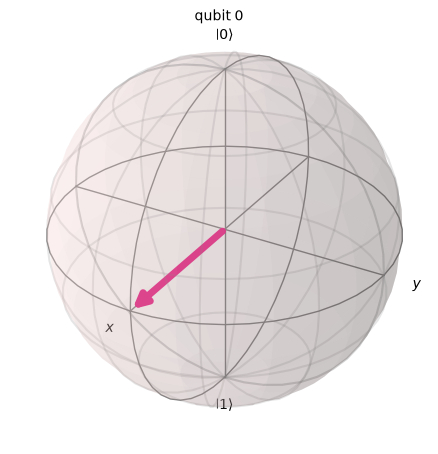

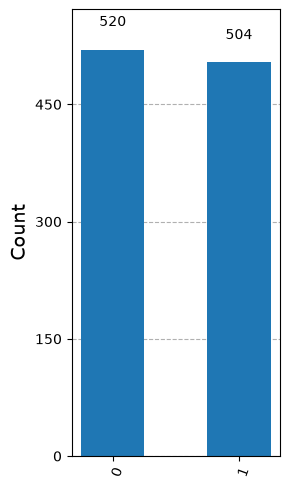

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer.primitives import SamplerV2
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import mark_inset, inset_axes

# define the backend
sampler = SamplerV2()

# defining the circuit
q = QuantumRegister(1, 'q')
c = ClassicalRegister(1, 'c')
circuit = QuantumCircuit(q,c)

# Define initial_state alpha=1, beta=0 --> state |0>
initial_state = [1,0]   
circuit.initialize(initial_state, 0) 

# A hadamard operation and measurement
circuit.h(q)



# statevector
state = Statevector(circuit)
print("state of qubit = " + np.array2string(np.round(state.data,3), separator=', '))


# visualize state in bloch sphere
display(plot_bloch_multivector(state))


# Add a measurement to the circuit
circuit.measure(q,c)

# execute the circuit with the defined backend
job = sampler.run([circuit]).result()

#visualize probability 

counts = job[0].data.c.get_counts()
display(plot_histogram(counts,figsize=(3,5)))

The Hadamard gate creates a state that is an even superposition of the basis states $|0\rangle$ and $|1\rangle$. 
It is only when we measure the qubit that we "collapse" the state to one of these values.
Using the qasm_simulator we can verify that indeed if we execute several times the circuit we will get in some cases ($\sim50%$) as output state $|0\rangle$ and in some cases ($\sim50%$) state $|1\rangle$.

> E1: change the backend to the qasm_simulator, uncomment the measurment and the probability section and comment out the statevector section. Is this what you expected?

> Q1: Can you also set a system in a superposition state with other gates? (hint: you need to align the state with the X-axis, maybe a rotation?)

> Q2: What is the effect of applying HXH? or HZH?

Many quantum gates can be expressed as a composition of other gates, and therefore a quantum computer doesn't need to directly implement every possible gate. The minimum set of gates needed to generate all operations is called a "universal gate set". As the name suggests, a universal gate set is a collection of gates expressive enough that any possible operation on a quantum computer can be reduced to a sequence of those gates.


This is similar to classical computers, where a (classical) gate set is called universal if, by stringing together enough gates from the set, you can express any Boolean function on any number of bits.

As a side note, all single qubit operations can be written in a general unitary form with three parameters: $U3(\theta, \phi, \lambda)$. Before running a circuit on a real quantum hardware, all single-qubit operations are compiled down to this form. For this reason, they are sometimes called the physical gates.